# 34 - 5-Fold Cross-Validation (Subject-Wise)

**Tujuan:** Evaluasi robustness model menggunakan 5-fold CV di mana user dikelompokkan ke 5 grup. Setiap fold, 1 grup (~7 user) menjadi test set.

**Perbedaan dengan LOSO:**
- LOSO: 37 fold (1 user/fold) → lebih detail tapi sangat lama
- 5-Fold CV: 5 fold (~7 user/fold) → lebih cepat, lebih stabil per fold

**3 model terbaik** (front-only 4-class):
1. Intermediate Fusion TL B1 (single split: 0.412)
2. Late Fusion B3 (single split: 0.394)
3. FCNN B3 (single split: 0.361)

**Estimasi:** ~2-4 jam (vs ~8-15 jam LOSO)

## 1. Setup

In [1]:
import sys, os, json
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from collections import Counter
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import KFold

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from training.models import (
    EmotionCNN, EmotionFCNN, IntermediateFusion,
    EmotionCNNTransfer, IntermediateFusionTransfer,
)
from training.utils import train_model, full_evaluation

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Config
DATASET_DIR = PROJECT_ROOT / "data" / "dataset_frontonly"
OUTPUT_DIR = PROJECT_ROOT / "models" / "frontonly" / "crossval"
os.makedirs(OUTPUT_DIR, exist_ok=True)

EMOTIONS_4 = ["neutral", "happy", "sad", "negative"]
REMAP_4 = {0: 0, 1: 1, 2: 2, 3: 3, 4: 3, 5: 3, 6: 3}
NUM_CLASSES = 4
K_FOLDS = 5
BATCH_SIZE = 16
EPOCHS = 50
PATIENCE = 15
SEED = 42

# Load all data
print("\nLoading numpy arrays...")
all_images = np.concatenate([
    np.load(DATASET_DIR / f"X_{s}_images.npy") for s in ["train", "val", "test"]])
all_landmarks = np.concatenate([
    np.load(DATASET_DIR / f"X_{s}_landmarks.npy") for s in ["train", "val", "test"]])
all_labels_7 = np.concatenate([
    np.load(DATASET_DIR / f"y_{s}.npy") for s in ["train", "val", "test"]])
all_labels = np.array([REMAP_4[int(l)] for l in all_labels_7], dtype=np.int64)
all_uids = np.load(DATASET_DIR / "user_ids_all.npy", allow_pickle=True)

users = sorted(set(all_uids))
user_indices = {uid: np.where(all_uids == uid)[0] for uid in users}

print(f"Total: {len(all_labels)} samples, {len(users)} users")
print(f"Class distribution (4-class): {dict(sorted(Counter(all_labels.tolist()).items()))}")

# Create 5-fold split (subject-wise)
rng = np.random.RandomState(SEED)
user_array = np.array(users)
rng.shuffle(user_array)
folds = np.array_split(user_array, K_FOLDS)

print(f"\n5-Fold Split (seed={SEED}):")
for i, fold_users in enumerate(folds):
    n_samples = sum(len(user_indices[u]) for u in fold_users)
    print(f"  Fold {i+1}: {list(fold_users)} ({len(fold_users)} users, {n_samples} samples)")

Device: cuda
GPU: Tesla T4

Loading numpy arrays...


Total: 7091 samples, 37 users
Class distribution (4-class): {0: 5836, 1: 683, 2: 435, 3: 137}

5-Fold Split (seed=42):
  Fold 1: [np.str_('118'), np.str_('114'), np.str_('104'), np.str_('211'), np.str_('97'), np.str_('207'), np.str_('107'), np.str_('208')] (8 users, 1864 samples)
  Fold 2: [np.str_('206'), np.str_('117'), np.str_('109'), np.str_('116'), np.str_('113'), np.str_('214'), np.str_('110'), np.str_('200')] (8 users, 1684 samples)
  Fold 3: [np.str_('100'), np.str_('213'), np.str_('106'), np.str_('112'), np.str_('101'), np.str_('209'), np.str_('202')] (7 users, 1024 samples)
  Fold 4: [np.str_('102'), np.str_('99'), np.str_('216'), np.str_('103'), np.str_('215'), np.str_('205'), np.str_('212')] (7 users, 1330 samples)
  Fold 5: [np.str_('111'), np.str_('203'), np.str_('197'), np.str_('201'), np.str_('108'), np.str_('115'), np.str_('210')] (7 users, 1189 samples)


## 2. Helper Functions

In [2]:
def make_loader(images, landmarks, labels, model_type, batch_size=32, shuffle=True):
    img_t = torch.from_numpy(images).permute(0, 3, 1, 2)
    lm_t = torch.from_numpy(landmarks)
    y_t = torch.from_numpy(labels).long()
    if model_type == "cnn":
        ds = TensorDataset(img_t, y_t)
    elif model_type == "fcnn":
        ds = TensorDataset(lm_t, y_t)
    else:
        ds = TensorDataset(img_t, lm_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=0, pin_memory=True, drop_last=(shuffle and len(ds) > batch_size))


def get_fold_indices(fold_idx):
    """Get train and test indices for a given fold."""
    test_users = folds[fold_idx]
    train_users = np.concatenate([folds[j] for j in range(K_FOLDS) if j != fold_idx])
    test_idx = np.concatenate([user_indices[u] for u in test_users])
    train_idx = np.concatenate([user_indices[u] for u in train_users])
    return train_idx, test_idx, list(test_users)


def train_fold_standard(ModelClass, model_type, lr, train_idx, test_idx, fold_dir):
    """Train a standard model (CNN, FCNN, Intermediate) for one fold."""
    train_img, train_lm, train_y = all_images[train_idx], all_landmarks[train_idx], all_labels[train_idx]
    test_img, test_lm, test_y = all_images[test_idx], all_landmarks[test_idx], all_labels[test_idx]

    # 10% val from train
    n_val = max(1, int(len(train_y) * 0.1))
    perm = np.random.RandomState(42).permutation(len(train_y))
    val_i, tr_i = perm[:n_val], perm[n_val:]

    tr_loader = make_loader(train_img[tr_i], train_lm[tr_i], train_y[tr_i], model_type, BATCH_SIZE)
    val_loader = make_loader(train_img[val_i], train_lm[val_i], train_y[val_i], model_type, BATCH_SIZE, False)
    test_loader = make_loader(test_img, test_lm, test_y, model_type, BATCH_SIZE, False)

    model = ModelClass(num_classes=NUM_CLASSES).to(device)
    save_path = str(fold_dir / "model.pth")
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=8, min_lr=1e-7)

    train_model(model, tr_loader, val_loader, nn.CrossEntropyLoss(), optimizer, scheduler,
                device, model_type, EPOCHS, PATIENCE, save_path)

    model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
    r = full_evaluation(model, test_loader, nn.CrossEntropyLoss(), device, model_type, EMOTIONS_4)
    os.remove(save_path)
    return {"test_accuracy": float(r["test_accuracy"]),
            "test_macro_f1": float(r["test_macro_f1"]),
            "test_weighted_f1": float(r["test_weighted_f1"])}


def train_fold_late_fusion(train_idx, test_idx, fold_dir):
    """Train CNN + FCNN, combine with weighted average."""
    train_img, train_lm, train_y = all_images[train_idx], all_landmarks[train_idx], all_labels[train_idx]
    test_img, test_lm, test_y = all_images[test_idx], all_landmarks[test_idx], all_labels[test_idx]

    n_val = max(1, int(len(train_y) * 0.1))
    perm = np.random.RandomState(42).permutation(len(train_y))
    val_i, tr_i = perm[:n_val], perm[n_val:]

    # Train CNN
    cnn = EmotionCNN(num_classes=NUM_CLASSES).to(device)
    cnn_tr = make_loader(train_img[tr_i], train_lm[tr_i], train_y[tr_i], "cnn", BATCH_SIZE)
    cnn_val = make_loader(train_img[val_i], train_lm[val_i], train_y[val_i], "cnn", BATCH_SIZE, False)
    cnn_opt = torch.optim.Adam(cnn.parameters(), lr=0.0001)
    cnn_sch = torch.optim.lr_scheduler.ReduceLROnPlateau(cnn_opt, mode="max", factor=0.5, patience=8, min_lr=1e-7)
    train_model(cnn, cnn_tr, cnn_val, nn.CrossEntropyLoss(), cnn_opt, cnn_sch,
                device, "cnn", EPOCHS, PATIENCE, str(fold_dir / "cnn.pth"))

    # Train FCNN
    fcnn = EmotionFCNN(num_classes=NUM_CLASSES).to(device)
    fcnn_tr = make_loader(train_img[tr_i], train_lm[tr_i], train_y[tr_i], "fcnn", BATCH_SIZE)
    fcnn_val = make_loader(train_img[val_i], train_lm[val_i], train_y[val_i], "fcnn", BATCH_SIZE, False)
    fcnn_opt = torch.optim.Adam(fcnn.parameters(), lr=0.0001)
    fcnn_sch = torch.optim.lr_scheduler.ReduceLROnPlateau(fcnn_opt, mode="max", factor=0.5, patience=8, min_lr=1e-7)
    train_model(fcnn, fcnn_tr, fcnn_val, nn.CrossEntropyLoss(), fcnn_opt, fcnn_sch,
                device, "fcnn", EPOCHS, PATIENCE, str(fold_dir / "fcnn.pth"))

    # Load best
    cnn.load_state_dict(torch.load(fold_dir / "cnn.pth", map_location=device, weights_only=True))
    fcnn.load_state_dict(torch.load(fold_dir / "fcnn.pth", map_location=device, weights_only=True))
    cnn.eval(); fcnn.eval()

    # Late fusion (batched)
    cnn_probs_list, fcnn_probs_list = [], []
    test_img_t = torch.from_numpy(test_img).permute(0, 3, 1, 2)
    test_lm_t = torch.from_numpy(test_lm)
    with torch.no_grad():
        for s in range(0, len(test_img), 16):
            cnn_probs_list.append(torch.softmax(cnn(test_img_t[s:s+16].to(device)), dim=1).cpu().numpy())
            fcnn_probs_list.append(torch.softmax(fcnn(test_lm_t[s:s+16].to(device)), dim=1).cpu().numpy())
    cnn_probs = np.concatenate(cnn_probs_list)
    fcnn_probs = np.concatenate(fcnn_probs_list)
    del cnn, fcnn, test_img_t, test_lm_t
    torch.cuda.empty_cache()

    best_f1, best_w = 0, 0.5
    for w in np.arange(0.0, 1.05, 0.05):
        preds = (w * cnn_probs + (1 - w) * fcnn_probs).argmax(axis=1)
        f1 = f1_score(test_y, preds, average="macro", zero_division=0)
        if f1 > best_f1:
            best_f1 = f1; best_w = w; best_preds = preds

    acc = accuracy_score(test_y, best_preds)
    wf1 = f1_score(test_y, best_preds, average="weighted", zero_division=0)

    os.remove(fold_dir / "cnn.pth")
    os.remove(fold_dir / "fcnn.pth")

    return {"test_accuracy": acc, "test_macro_f1": best_f1, "test_weighted_f1": wf1,
            "best_cnn_weight": best_w}


def run_crossval(model_name, ModelClass, model_type, lr, description):
    """Run 5-fold CV for one model."""
    is_late = (model_name == "late_fusion")
    print(f"\n{'='*70}")
    print(f"  5-FOLD CV: {description}")
    print(f"{'='*70}")

    model_dir = OUTPUT_DIR / f"{model_name}_4class"
    os.makedirs(model_dir, exist_ok=True)
    fold_results = []

    for fold_idx in range(K_FOLDS):
        train_idx, test_idx, test_users = get_fold_indices(fold_idx)
        n_test = len(test_idx)
        print(f"\n  Fold {fold_idx+1}/{K_FOLDS}: test={test_users} ({n_test} samples)")

        torch.cuda.empty_cache()
        fold_dir = model_dir / f"fold_{fold_idx+1}"
        os.makedirs(fold_dir, exist_ok=True)

        if is_late:
            r = train_fold_late_fusion(train_idx, test_idx, fold_dir)
        else:
            r = train_fold_standard(ModelClass, model_type, lr, train_idx, test_idx, fold_dir)

        r["fold"] = fold_idx + 1
        r["test_users"] = list(test_users)
        r["test_samples"] = n_test
        fold_results.append(r)
        print(f"    Acc={r['test_accuracy']:.4f}  Macro-F1={r['test_macro_f1']:.4f}  W-F1={r['test_weighted_f1']:.4f}")

        try: fold_dir.rmdir()
        except: pass

    # Summary
    accs = [r["test_accuracy"] for r in fold_results]
    f1s = [r["test_macro_f1"] for r in fold_results]
    wf1s = [r["test_weighted_f1"] for r in fold_results]

    print(f"\n  {'='*50}")
    print(f"  {description} — 5-Fold CV Results")
    print(f"  {'='*50}")
    print(f"  Accuracy:    {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"  Macro F1:    {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print(f"  Weighted F1: {np.mean(wf1s):.4f} ± {np.std(wf1s):.4f}")

    summary = {
        "model": model_name, "description": description,
        "num_classes": NUM_CLASSES, "k_folds": K_FOLDS,
        "seed": SEED, "total_users": len(users),
        "accuracy_mean": float(np.mean(accs)), "accuracy_std": float(np.std(accs)),
        "macro_f1_mean": float(np.mean(f1s)), "macro_f1_std": float(np.std(f1s)),
        "weighted_f1_mean": float(np.mean(wf1s)), "weighted_f1_std": float(np.std(wf1s)),
        "per_fold": fold_results,
    }
    save_path = OUTPUT_DIR / f"cv5_{model_name}_4class.json"
    with open(save_path, "w") as f:
        json.dump(summary, f, indent=2)
    print(f"  Saved: {save_path}")
    return summary

print("Helper functions ready.")

Helper functions ready.


## 3. Run 5-Fold CV

In [3]:
# 1. Intermediate Fusion TL (best single split: 0.412)
if (OUTPUT_DIR / "cv5_intermediate_tl_4class.json").exists():
    print("SKIP intermediate_tl — already exists")
    res_int_tl = json.load(open(OUTPUT_DIR / "cv5_intermediate_tl_4class.json"))
else:
    res_int_tl = run_crossval("intermediate_tl", IntermediateFusionTransfer, "fusion", 0.00005,
                           "Intermediate Fusion TL (ResNet18 + FCNN)")

# 2. Late Fusion (best single split: 0.394)
res_late = run_crossval("late_fusion", None, "late", 0.0001,
                         "Late Fusion (CNN + FCNN weighted avg)")

# 3. FCNN (best single split: 0.361)
res_fcnn = run_crossval("fcnn", EmotionFCNN, "fcnn", 0.0001,
                         "FCNN (Landmark only)")

SKIP intermediate_tl — already exists

  5-FOLD CV: Late Fusion (CNN + FCNN weighted avg)

  Fold 1/5: test=[np.str_('118'), np.str_('114'), np.str_('104'), np.str_('211'), np.str_('97'), np.str_('207'), np.str_('107'), np.str_('208')] (1864 samples)


 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      0.8839     0.6892     0.5280    0.8563   0.4057   0.000100  (31.9s)


     2      0.5072     0.8446     0.4804    0.8640   0.4896   0.000100  (31.7s)


     3      0.4536     0.8497     0.4314    0.8621   0.4963   0.000100  (31.3s)


...

    47      0.4445     0.8422     0.4865    0.8322   0.4523   0.000050  (1.2s)


    48      0.4519     0.8417     0.4487    0.8288   0.3825   0.000050  (1.1s)


    49      0.4383     0.8456     0.5326    0.8034   0.3299   0.000050  (1.1s)


    50      0.4420     0.8430     0.4568    0.8271   0.3900   0.000050  (1.1s)

Best: epoch 47, val_acc=0.8322, val_f1=0.4523
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/crossval/fcnn_4class/fold_5/model.pth
Test Loss: 0.5010
Test Accuracy: 0.8629
Test Macro F1: 0.3266
Test Weighted F1: 0.8300

Classification Report:
              precision    recall  f1-score   support

     neutral       0.90      0.97      0.93      1048
       happy       0.29      0.41      0.34        22
         sad       0.07      0.02      0.04        87
    negative       0.00      0.00      0.00        32

    accuracy                           0.86      1189
   macro avg       0.32      0.35      0.33      1189
weighted avg       0.80      0.86      0.83      1189



    Acc=0.8629  Macro-F1=0.3266  W-F1=0.8300

  FCNN (Landmark only) — 5-Fold CV Results
  Accuracy:    0.8275 ± 0.0430
  Macro F1:    0.3985 ± 0.0624
  Weighted F1: 0.8055 ± 0.0492
  Saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/crossval/cv5_fcnn_4class.json


## 4. Ringkasan 5-Fold CV

In [4]:
cv_dir = Path("../models/frontonly/crossval")

print("=" * 80)
print("RINGKASAN 5-FOLD CROSS-VALIDATION (4-CLASS FRONT-ONLY)")
print("=" * 80)
print(f"{'Model':<40} {'Macro F1':>18} {'Accuracy':>18} {'Folds':>6}")
print("-" * 85)

for f in sorted(cv_dir.glob("cv5_*_4class.json")):
    data = json.load(open(f))
    name = data['description']
    print(f"{name:<40} {data['macro_f1_mean']:.4f} ± {data['macro_f1_std']:.4f}"
          f"  {data['accuracy_mean']:.4f} ± {data['accuracy_std']:.4f}"
          f"  {data['k_folds']:>5}")

print()
print("Perbandingan:")
print(f"{'Metode':<20} {'Intermediate TL':>18} {'Late Fusion':>18} {'FCNN':>18}")
print("-" * 75)
print(f"{'Single Split':<20} {'0.412':>18} {'0.394':>18} {'0.361':>18}")

# Load CV results for comparison
for f in sorted(cv_dir.glob("cv5_*_4class.json")):
    data = json.load(open(f))
    # Will be printed in the LOSO comparison below

# Check if LOSO results exist
loso_dir = Path("../models/frontonly/loso")
if loso_dir.exists() and list(loso_dir.glob("loso_*_4class.json")):
    print()
    print("=" * 80)
    print("PERBANDINGAN: SINGLE SPLIT vs 5-FOLD CV vs LOSO")
    print("=" * 80)
    print(f"{'Model':<35} {'Single':>10} {'5-Fold CV':>18} {'LOSO':>18}")
    print("-" * 85)

    single_split = {
        "intermediate_tl": 0.412,
        "late_fusion": 0.394,
        "fcnn": 0.361,
    }
    model_names = {
        "intermediate_tl": "Intermediate TL",
        "late_fusion": "Late Fusion",
        "fcnn": "FCNN",
    }

    for model_key in ["intermediate_tl", "late_fusion", "fcnn"]:
        ss = single_split[model_key]
        cv_path = cv_dir / f"cv5_{model_key}_4class.json"
        loso_path = loso_dir / f"loso_{model_key}_4class.json"
        cv_str = "N/A"
        loso_str = "N/A"
        if cv_path.exists():
            cv = json.load(open(cv_path))
            cv_str = f"{cv['macro_f1_mean']:.4f} ± {cv['macro_f1_std']:.4f}"
        if loso_path.exists():
            lo = json.load(open(loso_path))
            loso_str = f"{lo['macro_f1_mean']:.4f} ± {lo['macro_f1_std']:.4f}"
        print(f"{model_names[model_key]:<35} {ss:>10.4f} {cv_str:>18} {loso_str:>18}")

RINGKASAN 5-FOLD CROSS-VALIDATION (4-CLASS FRONT-ONLY)
Model                                              Macro F1           Accuracy  Folds
-------------------------------------------------------------------------------------
FCNN (Landmark only)                     0.3985 ± 0.0624  0.8275 ± 0.0430      5
Intermediate Fusion TL (ResNet18 + FCNN) 0.4348 ± 0.0679  0.8082 ± 0.0951      5
Late Fusion (CNN + FCNN weighted avg)    0.4013 ± 0.0546  0.8203 ± 0.0724      5

Perbandingan:
Metode                  Intermediate TL        Late Fusion               FCNN
---------------------------------------------------------------------------
Single Split                      0.412              0.394              0.361

PERBANDINGAN: SINGLE SPLIT vs 5-FOLD CV vs LOSO
Model                                   Single          5-Fold CV               LOSO
-------------------------------------------------------------------------------------
Intermediate TL                         0.4120    0.4348 ± 0.06

## 5. Visualisasi Per-Fold

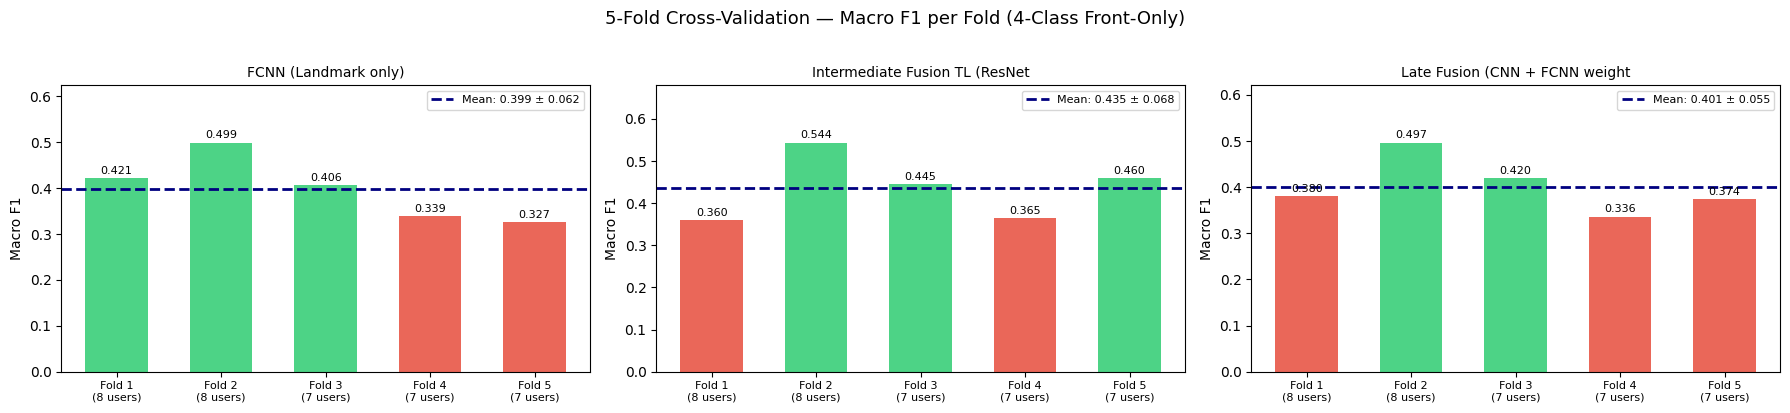

Chart saved to ../models/frontonly/crossval/cv5_comparison.png


In [5]:
import matplotlib.pyplot as plt

files = sorted(cv_dir.glob("cv5_*_4class.json"))
fig, axes = plt.subplots(1, len(files), figsize=(6 * len(files), 4))
if len(files) == 1:
    axes = [axes]

for ax, f in zip(axes, files):
    data = json.load(open(f))
    folds_data = data['per_fold']
    fold_labels = [f"Fold {r['fold']}\n({len(r['test_users'])} users)" for r in folds_data]
    f1s = [r['test_macro_f1'] for r in folds_data]

    colors = ['#2ecc71' if f1 >= np.mean(f1s) else '#e74c3c' for f1 in f1s]
    bars = ax.bar(range(len(f1s)), f1s, color=colors, alpha=0.85, width=0.6)
    ax.axhline(y=np.mean(f1s), color='navy', linestyle='--', linewidth=2,
               label=f"Mean: {np.mean(f1s):.3f} ± {np.std(f1s):.3f}")
    ax.set_xticks(range(len(f1s)))
    ax.set_xticklabels(fold_labels, fontsize=8)
    ax.set_ylabel('Macro F1')
    ax.set_title(data['description'][:30], fontsize=10)
    ax.legend(fontsize=8)
    ax.set_ylim(0, max(f1s) * 1.25)

    # Add value labels
    for bar, val in zip(bars, f1s):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('5-Fold Cross-Validation — Macro F1 per Fold (4-Class Front-Only)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(str(cv_dir / 'cv5_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Chart saved to {cv_dir / 'cv5_comparison.png'}")